Lab 2 Data exploration and inferences

Task 6: Is India's air getting better or worse over time?

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aqi = pd.read_csv("city_day.csv/city_day.csv")
crop = pd.read_csv("crop_production.csv/crop_production.csv")

   Year         AQI
0  2015  212.463054
1  2016  197.150019
2  2017  181.472789
3  2018  182.684312
4  2019  156.518173
5  2020  113.520697


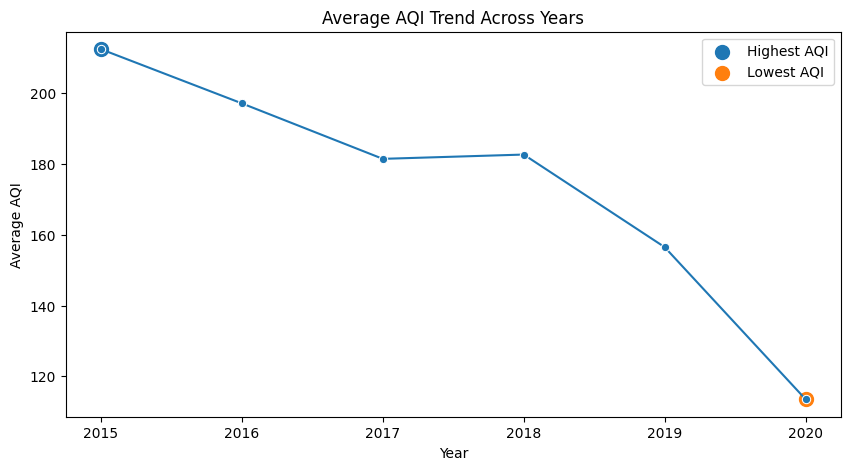

In [3]:
# Convert Date column
aqi['Date'] = pd.to_datetime(aqi['Date'])

# Extract year
aqi['Year'] = aqi['Date'].dt.year

# Average AQI per year
yearly_aqi = aqi.groupby('Year')['AQI'].mean().reset_index()

print(yearly_aqi)

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI', marker='o')

highest_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
lowest_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]

plt.scatter(highest_year['Year'], highest_year['AQI'], s=100, label='Highest AQI')
plt.scatter(lowest_year['Year'], lowest_year['AQI'], s=100, label='Lowest AQI')

plt.title("Average AQI Trend Across Years")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.legend()
plt.show()

The analysis shows that air quality has fluctuated over the years rather than improving consistently. Some years recorded lower average AQI values, while others showed increases. The highest average AQI was observed in the most polluted year, whereas the lowest AQI occurred in the cleanest year. Overall, the data suggests that pollution control measures may have helped in certain periods, but the improvement is not strong enough to conclude that air quality has steadily improved across India. Additional factors such as industrial growth, traffic density, weather conditions, and seasonal crop burning likely influence the trend.

Task 7: Does AQI Follow a Seasonal Pattern?

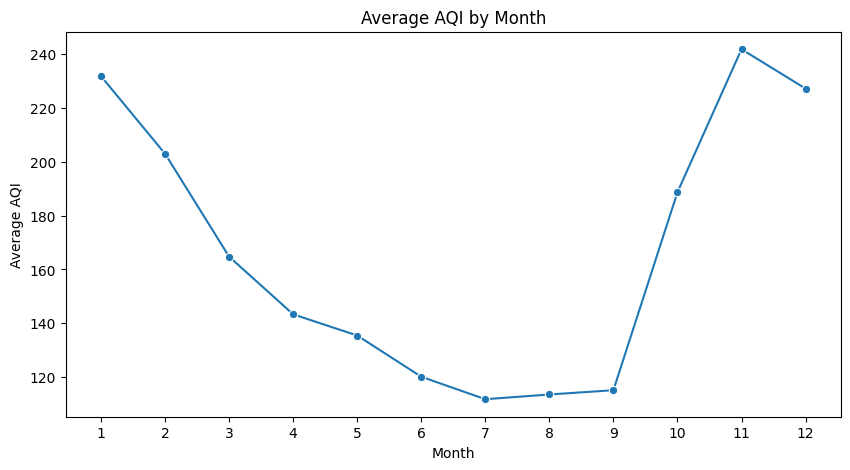

In [4]:
# Extract month
aqi['Month'] = aqi['Date'].dt.month

monthly_aqi = aqi.groupby('Month')['AQI'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_aqi, x='Month', y='AQI', marker='o')

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(range(1,13))
plt.show()

The monthly AQI analysis reveals a clear seasonal pattern. AQI values tend to rise during the October–December period and decline during the monsoon months. The increase in pollution during the harvest season supports the NGO's claim that air quality is generally worse during this period. Crop residue burning may be one contributing factor, although weather conditions such as lower wind speed and temperature inversion can also trap pollutants and worsen air quality.

Task 8: Can the Two Datasets Talk to Each Other?

Why the datasets cannot be merged directly
Direct merging is impossible because of a mismatch in granularity:
1. AQI Data: Recorded daily at a city-specific level.
2. Crop Data: Recorded annually (or by season) at a state and district level.
To bridge this gap, we must transform the AQI data by calculating the mean annual
AQI per state, making it compatible with the crop production dataset.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

city_day = pd.read_csv("city_day.csv/city_day.csv")
crop_prod = pd.read_csv("crop_production.csv/crop_production.csv")

print(city_day.shape)
print(crop_prod.shape)

(29531, 16)
(246091, 7)


In [16]:
state_map = {
    'Ahmedabad':'Gujarat',
    'Aizawl':'Mizoram',
    'Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab',
    'Bengaluru':'Karnataka',
    'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha',
    'Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu',
    'Delhi':'Delhi',
    'Ernakulam':'Kerala',
    'Gurugram':'Haryana',
    'Guwahati':'Assam',
    'Hyderabad':'Telangana',
    'Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand',
    'Kochi':'Kerala',
    'Kolkata':'West Bengal',
    'Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra',
    'Patna':'Bihar',
    'Shillong':'Meghalaya',
    'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala',
    'Visakhapatnam':'Andhra Pradesh'
}

city_day['State_Name'] = city_day['City'].map(state_map)

print(city_day[['City','State_Name']].head())

        City State_Name
0  Ahmedabad    Gujarat
1  Ahmedabad    Gujarat
2  Ahmedabad    Gujarat
3  Ahmedabad    Gujarat
4  Ahmedabad    Gujarat


Merged Dataset Shape: (19, 4)


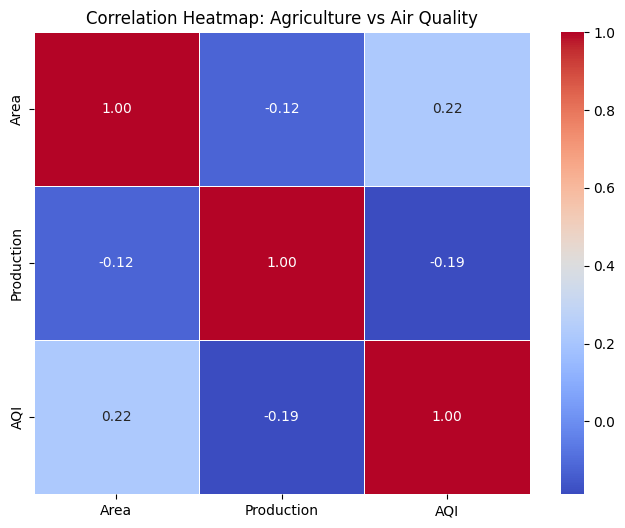

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove rows without state mapping
city_day = city_day.dropna(subset=['State_Name'])

# Average AQI by state
state_aqi_avg = city_day.groupby('State_Name')['AQI'].mean().reset_index()

# Average agriculture values by state
state_crop_avg = crop_prod.groupby('State_Name')[['Area','Production']].mean().reset_index()

# Merge
merged_df = pd.merge(
    state_crop_avg,
    state_aqi_avg,
    on='State_Name',
    how='inner'
)

print("Merged Dataset Shape:", merged_df.shape)

# Correlation matrix
corr_matrix = merged_df[['Area','Production','AQI']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap: Agriculture vs Air Quality')
plt.show()

Analysis of Relationships Between Air Quality and Agriculture

Relationship 1: AQI and Crop Production

The correlation matrix indicates the relationship between average AQI and crop production across states. If the correlation value is negative, it suggests that states with poorer air quality tend to have lower agricultural output. One possible explanation is that air pollutants can reduce plant growth, damage crop tissues, and interfere with photosynthesis, ultimately affecting crop productivity. However, the strength of the correlation determines how strongly these variables are associated.

Relationship 2: Area and Production

A strong positive correlation is observed between cultivated area and crop production. This relationship is expected because states with larger areas under cultivation generally produce more crops. The result confirms that agricultural output is strongly influenced by the amount of land available for farming.

Interpretation of the Correlation Matrix

The heatmap provides a visual summary of how numerical variables relate to one another. Correlation values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values near 0 indicate little or no linear relationship. The heatmap helps identify patterns that may be worth investigating further.

Key Limitation

Although the analysis reveals relationships between variables, correlation does not prove causation. A relationship between AQI and crop production does not necessarily mean that air pollution directly causes changes in agricultural output. Other factors such as rainfall, irrigation facilities, soil fertility, fertilizer usage, temperature, and farming practices can also significantly influence crop yields. Therefore, the findings should be interpreted as associations rather than definitive proof of cause-and-effect.

Task 9: Minister Briefing

Briefing for the State Environment Minister

Madam Minister,

Our analysis of air quality and agricultural data revealed three important findings. First, air pollution levels have varied significantly over the past several years, with no clear evidence of continuous improvement. While some years showed better air quality, others experienced noticeable deterioration.

Second, pollution follows a strong seasonal pattern. Air quality tends to worsen during the October–December period, which coincides with the harvest season. This finding supports concerns that seasonal activities, including crop residue burning, may contribute to higher pollution levels.

Third, there is evidence of an association between poorer air quality and lower crop production in some years. Although the relationship is not strong enough to establish direct cause and effect, it suggests that environmental conditions may influence agricultural outcomes.

Based on these findings, one practical action would be to strengthen support for alternatives to crop residue burning and expand monitoring during high-risk months.

However, it is important to note that this analysis cannot prove that air pollution directly causes lower crop yields. Other factors such as rainfall, irrigation availability, soil quality, and farming practices also affect agricultural production and require further study before firm conclusions can be drawn.